# Data Science Project Competition - July 2026 Edition

# E-Commerce Return Abuse & Wardrobing Risk Engine

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [7]:
df = pd.read_csv('Test_clean.csv',parse_dates=['order_date', 'delivery_date', 'return_date'])
df.head()

,customer_id,order_id,order_item_id,product_id,customer_tenure_days,membership_type,lifetime_spend,total_orders,total_returns,return_rate,...,item_condition,missing_tags,worn_signs,scratches,stains,packaging_damage,complaint_count,average_resolution_time,sentiment,fraud_label
0,CUST00041,ORDV3000001,ITEMV3000001,prod06855,969,gold,52411.53,58,14,0.241,...,poor,no,yes,yes,yes,no,1.0,61.8,negative,0
1,CUST16311,ORDV3000002,ITEMV3000002,prod06691,2327,platinum,37460.18,120,20,0.167,...,poor,no,no,yes,yes,yes,7.0,28.4,positive,0
2,CUST01353,ORDV3000003,ITEMV3000003,prod00091,1776,silver,11499.08,21,8,0.381,...,good,yes,yes,no,no,no,8.0,49.3,negative,1
3,CUST17397,ORDV3000004,ITEMV3000004,prod07999,864,silver,80132.54,109,54,0.495,...,poor,no,no,no,no,no,3.0,11.0,neutral,1
4,CUST16220,ORDV3000005,ITEMV3000005,prod01157,1546,silver,79857.25,110,49,0.445,...,poor,no,no,no,yes,no,0.0,49.8,neutral,0


In [8]:
df.dtypes

customer_id                        object
order_id                           object
order_item_id                      object
product_id                         object
customer_tenure_days                int64
membership_type                    object
lifetime_spend                    float64
total_orders                        int64
total_returns                       int64
return_rate                       float64
average_order_value               float64
purchase_frequency                float64
category                           object
brand                              object
selling_price                     float64
luxury_flag                        object
order_date                 datetime64[ns]
delivery_date              datetime64[ns]
delivery_delay                    float64
quantity                            int64
order_amount                      float64
discount                          float64
coupon_used                        object
payment_method                    

## 3. Customer Segmentation using KMeans

In [9]:
df1 = df.copy()

### 3.1 Feature Selection

In [10]:
x = df1.drop(['customer_id','order_id','order_item_id','product_id','order_date','fraud_label','delivery_date','return_date',
             'membership_type','category','brand','luxury_flag','coupon_used','payment_method','return_reason',
             'previous_return_reason','item_condition','missing_tags','worn_signs','scratches','stains','packaging_damage',
              'sentiment','quantity','selling_price','order_amount','discount','refund_amount','return_days','delivery_delay',
              'complaint_count','average_resolution_time'], axis=1)

print(x.shape)

(47545, 7)


In [11]:
x.columns

Index(['customer_tenure_days', 'lifetime_spend', 'total_orders',
       'total_returns', 'return_rate', 'average_order_value',
       'purchase_frequency'],
      dtype='object')

### 3.2 Data Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

### 3.3 Model Building

In [13]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

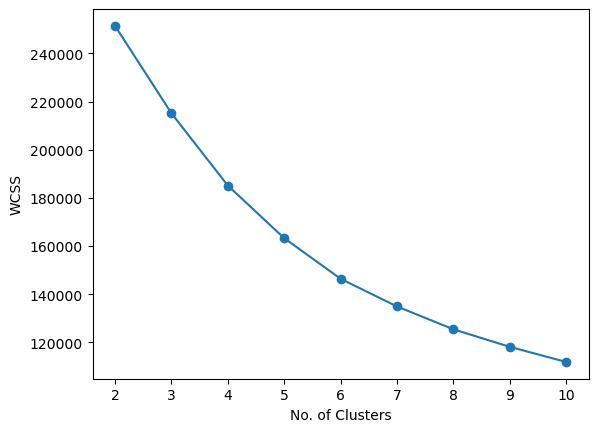

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
from sklearn.metrics import silhouette_score

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"{i} Clusters : {score:.3f}")

2 Clusters : 0.246
3 Clusters : 0.252
4 Clusters : 0.225
5 Clusters : 0.207
6 Clusters : 0.211
7 Clusters : 0.205
8 Clusters : 0.203
9 Clusters : 0.210
10 Clusters : 0.207


In [16]:
from sklearn.cluster import KMeans

In [17]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20)

clusters = kmeans.fit_predict(X_scaled)

In [18]:
x['Cluster'] = clusters

In [19]:
x['Cluster'].value_counts()

Cluster
0    26676
2    17919
1     2950
Name: count, dtype: int64

In [20]:
x.groupby('Cluster').mean(numeric_only=True).T

Cluster,0,1,2
customer_tenure_days,1300.346041,146.520678,1401.023495
lifetime_spend,13137.180852,37415.192817,47770.051933
total_orders,38.238079,84.854576,89.345778
total_returns,7.138552,20.759661,25.844857
return_rate,0.217760,0.247236,0.296560
average_order_value,397.855962,448.621349,548.267428
purchase_frequency,1.406365,20.279715,2.622387


In [21]:
cluster_names = {
    0: "Loyal Low-Return Customers",
    1: "Active Frequent Shoppers",
    2: "High-Value High-Return Customers"
}

x["Customer_Segment"] = x["Cluster"].map(cluster_names)

In [22]:
x["Customer_Segment"].value_counts()

Customer_Segment
Loyal Low-Return Customers          26676
High-Value High-Return Customers    17919
Active Frequent Shoppers             2950
Name: count, dtype: int64

### 3.4 Saving Model

In [45]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))

## 4. Fraud Detection using Classification

### 4.1 Encoding - Dummy Variable Creation

In [46]:
df.columns

Index(['customer_id', 'order_id', 'order_item_id', 'product_id',
       'customer_tenure_days', 'membership_type', 'lifetime_spend',
       'total_orders', 'total_returns', 'return_rate', 'average_order_value',
       'purchase_frequency', 'category', 'brand', 'selling_price',
       'luxury_flag', 'order_date', 'delivery_date', 'delivery_delay',
       'quantity', 'order_amount', 'discount', 'coupon_used', 'payment_method',
       'return_date', 'return_days', 'return_reason', 'refund_amount',
       'previous_return_reason', 'item_condition', 'missing_tags',
       'worn_signs', 'scratches', 'stains', 'packaging_damage',
       'complaint_count', 'average_resolution_time', 'sentiment',
       'fraud_label'],
      dtype='object')

In [47]:
cat_cols = df.dtypes[df.dtypes==object].index
print(cat_cols)

Index(['customer_id', 'order_id', 'order_item_id', 'product_id',
       'membership_type', 'category', 'brand', 'luxury_flag', 'coupon_used',
       'payment_method', 'return_reason', 'previous_return_reason',
       'item_condition', 'missing_tags', 'worn_signs', 'scratches', 'stains',
       'packaging_damage', 'sentiment'],
      dtype='object')


In [48]:
cols_2encode = ['membership_type','category','luxury_flag','payment_method','return_reason',
    'item_condition','missing_tags','worn_signs','scratches','stains','packaging_damage',
    'sentiment']

In [49]:
df_dummies = pd.get_dummies(data=df,columns=cols_2encode,dtype=int,drop_first=True)
print(df_dummies.columns)
print(df_dummies.shape)

Index(['customer_id', 'order_id', 'order_item_id', 'product_id',
       'customer_tenure_days', 'lifetime_spend', 'total_orders',
       'total_returns', 'return_rate', 'average_order_value',
       'purchase_frequency', 'brand', 'selling_price', 'order_date',
       'delivery_date', 'delivery_delay', 'quantity', 'order_amount',
       'discount', 'coupon_used', 'return_date', 'return_days',
       'refund_amount', 'previous_return_reason', 'complaint_count',
       'average_resolution_time', 'fraud_label', 'membership_type_gold',
       'membership_type_platinum', 'membership_type_silver',
       'category_electronics', 'category_fashion', 'category_home',
       'category_shoes', 'category_sports', 'luxury_flag_yes',
       'payment_method_cod', 'payment_method_netbanking', 'payment_method_upi',
       'payment_method_wallet', 'return_reason_damaged',
       'return_reason_defective', 'return_reason_late delivery',
       'return_reason_wrong item', 'return_reason_wrong size',
      

### 4.2 Selecting x and y

In [50]:
x = df_dummies.drop(['customer_id','order_id','order_item_id','product_id','order_date','delivery_date',
             'return_date','previous_return_reason','brand','coupon_used','fraud_label'], axis=1)
y = df_dummies['fraud_label']
print(x.shape)
print(y.shape)

(47545, 44)
(47545,)


In [51]:
x.columns

Index(['customer_tenure_days', 'lifetime_spend', 'total_orders',
       'total_returns', 'return_rate', 'average_order_value',
       'purchase_frequency', 'selling_price', 'delivery_delay', 'quantity',
       'order_amount', 'discount', 'return_days', 'refund_amount',
       'complaint_count', 'average_resolution_time', 'membership_type_gold',
       'membership_type_platinum', 'membership_type_silver',
       'category_electronics', 'category_fashion', 'category_home',
       'category_shoes', 'category_sports', 'luxury_flag_yes',
       'payment_method_cod', 'payment_method_netbanking', 'payment_method_upi',
       'payment_method_wallet', 'return_reason_damaged',
       'return_reason_defective', 'return_reason_late delivery',
       'return_reason_wrong item', 'return_reason_wrong size',
       'item_condition_fair', 'item_condition_good', 'item_condition_poor',
       'missing_tags_yes', 'worn_signs_yes', 'scratches_yes', 'stains_yes',
       'packaging_damage_yes', 'sentiment_ne

### 4.3 Splitting Data

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(33281, 44) (14264, 44)
(33281,) (14264,)


### 4.4 Creating Function to Evaluate Performance

In [54]:
from sklearn.metrics import *

In [55]:
def eval_model(x_train,x_test,y_train,y_test,model,mname):
    model.fit(x_train,y_train)
    ypred = model.predict(x_test)

    train_acc = model.score(x_train,y_train)
    test_acc = model.score(x_test,y_test)
    pre0 = precision_score(y_test,ypred,pos_label=0)
    pre1 = precision_score(y_test,ypred,pos_label=1)
    rec0 = recall_score(y_test,ypred,pos_label=0)
    rec1 = recall_score(y_test,ypred,pos_label=1)
    f1_s0 = f1_score(y_test,ypred,pos_label=0)
    f1_s1 = f1_score(y_test,ypred,pos_label=1)

    evals = {'Train_Acc':train_acc,'Test_acc':test_acc,'Pre0':pre0,'Pre1':pre1,
            'rec0':rec0,'rec1':rec1,'F1_score0':f1_s0,'F1_Score1':f1_s1}
    eval_df = pd.DataFrame(evals,index=[mname])
    return ypred, eval_df

### 4.5 Model Building

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#### 4.5.1 Logistic Regression

In [57]:
lr = LogisticRegression(max_iter=100000)
ypred_lr, lr_df = eval_model(x_train, x_test, y_train, y_test, lr, "LogisticRegression")
lr_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
LogisticRegression,0.810523,0.813236,0.837713,0.7571,0.887763,0.670415,0.862012,0.711126


#### 4.5.2 KNeighbors

In [58]:
knn = KNeighborsClassifier(n_neighbors=11)
ypred_knn, knn_df = eval_model(x_train, x_test, y_train, y_test, knn, "KNeighborsClassifier")
knn_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
KNeighborsClassifier,0.686398,0.618831,0.664741,0.382226,0.847221,0.181149,0.744969,0.245804


#### 4.5.3 Decision Tree

In [59]:
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=4,min_samples_split=10)
ypred_dt1, dt1_df = eval_model(x_train, x_test, y_train, y_test, dt1, "DecisionTreeClassifier")
dt1_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
DecisionTreeClassifier,0.844476,0.849621,0.889692,0.77515,0.880294,0.79084,0.884968,0.782917


#### 4.5.4 Random Forest

In [60]:
rf1 = RandomForestClassifier(n_estimators=90,criterion='entropy',max_depth=6,min_samples_split=8)
ypred_rf1, rf1_df = eval_model(x_train, x_test, y_train, y_test, rf1, "RandomForestClassifier")
rf1_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
RandomForestClassifier,0.836393,0.833006,0.82483,0.858122,0.946975,0.614598,0.881693,0.716226


#### 4.5.5 AdaBoost

In [61]:
ad1 = AdaBoostClassifier(n_estimators=85) #(depth=1)
ypred_ad1, ad1_df = eval_model(x_train, x_test, y_train, y_test, ad1, "AdaBoostClassifier")
ad1_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
AdaBoostClassifier,0.864758,0.865185,0.868156,0.857935,0.93716,0.727254,0.901339,0.787208


#### 4.5.6 Gradient Boost

In [62]:
gbc = GradientBoostingClassifier(n_estimators=85,min_samples_split=5,max_depth=5)
ypred_gbc, gbc_df = eval_model(x_train, x_test, y_train, y_test, gbc, "GradientBoostingClassifier")
gbc_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
GradientBoostingClassifier,0.918121,0.922813,0.959658,0.859856,0.921263,0.925782,0.940069,0.891602


#### 4.5.7 XGBoost

In [63]:
XG1 = XGBClassifier(objective='binary:logistic',eval_metric='logloss',reg_lambda=0.2,eta=0.25,gamma=0.3)
ypred_XG1, XG1_df = eval_model(x_train, x_test, y_train, y_test, XG1, "XGBClassifier")
XG1_df

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
XGBClassifier,0.944353,0.918746,0.952712,0.859399,0.922117,0.912288,0.937165,0.885054


#### Comparing Models

In [64]:
all_evals = pd.concat([lr_df,knn_df,dt1_df,rf1_df,ad1_df,XG1_df,gbc_df])
all_evals

,Train_Acc,Test_acc,Pre0,Pre1,rec0,rec1,F1_score0,F1_Score1
LogisticRegression,0.810523,0.813236,0.837713,0.757100,0.887763,0.670415,0.862012,0.711126
KNeighborsClassifier,0.686398,0.618831,0.664741,0.382226,0.847221,0.181149,0.744969,0.245804
DecisionTreeClassifier,0.844476,0.849621,0.889692,0.775150,0.880294,0.790840,0.884968,0.782917
RandomForestClassifier,0.836393,0.833006,0.824830,0.858122,0.946975,0.614598,0.881693,0.716226
AdaBoostClassifier,0.864758,0.865185,0.868156,0.857935,0.937160,0.727254,0.901339,0.787208
XGBClassifier,0.944353,0.918746,0.952712,0.859399,0.922117,0.912288,0.937165,0.885054
GradientBoostingClassifier,0.918121,0.922813,0.959658,0.859856,0.921263,0.925782,0.940069,0.891602


### 4.6 Saving The Best Performing Model

In [65]:
import pickle
pickle.dump(gbc,open('gbc_Fraud_Detection.pkl','wb'))